In [1]:
pip install sqlalchemy pymysql pandas matplotlib seaborn python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [2]:
import datetime
import requests
import json
import os

from dotenv import load_dotenv
import pandas as pd
import sqlalchemy as sa
from sqlalchemy import create_engine, text, MetaData, Table
from sqlalchemy.orm import sessionmaker

In [6]:
import os
import datetime
import requests
import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from sqlalchemy import create_engine, text

In [ ]:
Завдання 1: Створення таблиці курсів валют та API інтеграція

In [9]:
def create_currency_table(engine):
    create_table_sql = text("""
    CREATE TABLE IF NOT EXISTS currency_rates (
        id INT AUTO_INCREMENT PRIMARY KEY,
        currency_code VARCHAR(3) NOT NULL,
        rate_to_usd DECIMAL(10, 6) NOT NULL,
        rate_date DATE NOT NULL,
        created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
        updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
            ON UPDATE CURRENT_TIMESTAMP,
        INDEX idx_currency_date (currency_code, rate_date),
        UNIQUE KEY unique_currency_date (currency_code, rate_date)
    )
    """)

    with engine.connect() as conn:
        conn.execute(create_table_sql)

    print("✅ Таблиця currency_rates створена")


create_currency_table(engine)

✅ Таблиця currency_rates створена


In [10]:
verification_df = pd.read_sql(
    """
    SELECT *
    FROM currency_rates;
    """,
    engine
)

display(verification_df)

,id,currency_code,rate_to_usd,rate_date,created_at,updated_at


In [11]:
def fetch_exchange_rates():
    url = "https://api.exchangerate-api.com/v4/latest/USD"

    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()

        data = response.json()

        # Потрібні за умовою валюти
        currencies = ["EUR", "UAH"]

        rates = {}

        for currency in currencies:
            if currency in data["rates"]:
                rates[currency] = data["rates"][currency]

        return rates, datetime.date.today()

    except Exception as e:
        print(f"❌ Помилка API: {e}")
        return None, None

In [12]:
def save_exchange_rates(engine, rates_dict, rate_date):

    if not rates_dict:
        print("❌ Немає даних для збереження")
        return False

    insert_sql = text("""
    INSERT INTO currency_rates
        (currency_code, rate_to_usd, rate_date)
    VALUES
        (:currency, :rate, :date)
    ON DUPLICATE KEY UPDATE
        rate_to_usd = VALUES(rate_to_usd),
        updated_at = CURRENT_TIMESTAMP
    """)

    try:
        with engine.connect() as conn:
            with conn.begin():
                for currency, rate in rates_dict.items():
                    conn.execute(
                        insert_sql,
                        {
                            "currency": currency,
                            "rate": rate,
                            "date": rate_date
                        }
                    )

        print(
            f"✅ Збережено {len(rates_dict)} курсів "
            f"валют на {rate_date}"
        )
        return True

    except Exception as e:
        print(f"❌ Помилка збереження: {e}")
        return False

In [13]:
print("📡 Отримуємо курси валют...")

rates, rate_date = fetch_exchange_rates()

if rates:
    print(f"\nКурси на {rate_date}:")

    for currency, rate in rates.items():
        print(f"1 USD = {rate:.6f} {currency}")

    save_exchange_rates(
        engine,
        rates,
        rate_date
    )

📡 Отримуємо курси валют...

Курси на 2026-10-06:
1 USD = 0.892000 EUR
1 USD = 45.070000 UAH
✅ Збережено 2 курсів валют на 2026-10-06


In [14]:
verification_df = pd.read_sql(
    """
    SELECT
        id,
        currency_code,
        rate_to_usd,
        rate_date,
        created_at,
        updated_at
    FROM currency_rates
    ORDER BY rate_date DESC, currency_code
    """,
    engine
)

display(verification_df)

,id,currency_code,rate_to_usd,rate_date,created_at,updated_at
0,1,EUR,0.892,2026-10-06,2026-10-06 13:48:06,2026-10-06 13:48:06
1,2,UAH,45.070,2026-10-06,2026-10-06 13:48:06,2026-10-06 13:48:06


In [ ]:
Завдання 2: Створення простого ETL пайплайну

In [16]:
print("📥 EXTRACT — витягування даних...")

sales_query = text("""
SELECT
    o.orderNumber,
    o.orderDate,
    o.status,

    od.productCode,
    od.quantityOrdered,
    od.priceEach,

    p.productName,
    p.productLine,
    p.productScale,
    p.productVendor,
    p.buyPrice,
    p.MSRP,

    c.customerNumber,
    c.customerName,
    c.country,
    c.city

FROM orders AS o

INNER JOIN orderdetails AS od
    ON o.orderNumber = od.orderNumber

INNER JOIN products AS p
    ON od.productCode = p.productCode

INNER JOIN customers AS c
    ON o.customerNumber = c.customerNumber

WHERE YEAR(o.orderDate) = 2004
ORDER BY o.orderDate, o.orderNumber
""")

df_sales = pd.read_sql(
    sales_query,
    engine,
    parse_dates=["orderDate"]
)

print(f"✅ Завантажено рядків продажів: {len(df_sales)}")

display(df_sales.head())

📥 EXTRACT — витягування даних...
✅ Завантажено рядків продажів: 1421


,orderNumber,orderDate,status,productCode,quantityOrdered,priceEach,productName,productLine,productScale,productVendor,buyPrice,MSRP,customerNumber,customerName,country,city
0,10208,2004-01-02,Shipped,S12_1108,46,176.63,2001 Ferrari Enzo,Classic Cars,1:12,Second Gear Diecast,95.59,207.80,146,"Saveley & Henriot, Co.",France,Lyon
1,10208,2004-01-02,Shipped,S12_3148,26,128.42,1969 Corvair Monza,Classic Cars,1:18,Welly Diecast Productions,89.14,151.08,146,"Saveley & Henriot, Co.",France,Lyon
2,10208,2004-01-02,Shipped,S12_3891,20,152.26,1969 Ford Falcon,Classic Cars,1:12,Second Gear Diecast,83.05,173.02,146,"Saveley & Henriot, Co.",France,Lyon
3,10208,2004-01-02,Shipped,S18_3140,24,117.47,1903 Ford Model A,Vintage Cars,1:18,Unimax Art Galleries,68.30,136.59,146,"Saveley & Henriot, Co.",France,Lyon
4,10208,2004-01-02,Shipped,S18_3259,48,96.81,Collectable Wooden Train,Trains,1:18,Carousel DieCast Legends,67.56,100.84,146,"Saveley & Henriot, Co.",France,Lyon


In [17]:
print("Мінімальна дата:", df_sales["orderDate"].min())
print("Максимальна дата:", df_sales["orderDate"].max())

print("\nРоки:")
print(df_sales["orderDate"].dt.year.value_counts())

Мінімальна дата: 2004-01-02 00:00:00
Максимальна дата: 2004-12-17 00:00:00

Роки:
orderDate
2004    1421
Name: count, dtype: int64


In [18]:
products_query = text("""
SELECT
    productCode,
    productName,
    productLine,
    buyPrice,
    MSRP
FROM products
ORDER BY productLine, productName
""")

df_products = pd.read_sql(
    products_query,
    engine
)

print(f"✅ Завантажено продуктів: {len(df_products)}")

display(df_products.head())

✅ Завантажено продуктів: 110


,productCode,productName,productLine,buyPrice,MSRP
0,S18_1889,1948 Porsche 356-A Roadster,Classic Cars,53.90,77.00
1,S18_3685,1948 Porsche Type 356 Roadster,Classic Cars,62.16,141.28
2,S24_2766,1949 Jaguar XK 120,Classic Cars,47.25,90.87
3,S10_1949,1952 Alpine Renault 1300,Classic Cars,98.58,214.30
4,S24_2887,1952 Citroen-15CV,Classic Cars,72.82,117.44


In [19]:
currency_query = text("""
SELECT
    currency_code,
    rate_to_usd,
    rate_date
FROM currency_rates
WHERE currency_code IN ('EUR', 'UAH')
ORDER BY rate_date DESC
""")

df_currencies = pd.read_sql(
    currency_query,
    engine,
    parse_dates=["rate_date"]
)

print(f"✅ Завантажено курсів валют: {len(df_currencies)}")

display(df_currencies)

✅ Завантажено курсів валют: 2


,currency_code,rate_to_usd,rate_date
0,EUR,0.892,2026-10-06
1,UAH,45.070,2026-10-06


In [20]:
eur_rows = df_currencies[
    df_currencies["currency_code"] == "EUR"
]

if eur_rows.empty:
    raise ValueError("❌ У таблиці currency_rates немає курсу EUR")

eur_rate = eur_rows.iloc[0]["rate_to_usd"]

print(f"EUR rate: {eur_rate}")

EUR rate: 0.892


In [21]:
print("🔧 TRANSFORM — обробка даних...")

# Загальна сума товарної позиції
df_sales["total_amount"] = (
    df_sales["priceEach"] *
    df_sales["quantityOrdered"]
)

# Прибуток з одного товару
df_sales["profit_per_item"] = (
    df_sales["priceEach"] -
    df_sales["buyPrice"]
)

# Загальний прибуток товарної позиції
df_sales["total_profit"] = (
    df_sales["profit_per_item"] *
    df_sales["quantityOrdered"]
)

# Сума в EUR
df_sales["total_amount_eur"] = (
    df_sales["total_amount"] /
    eur_rate
)

print("✅ Розрахункові колонки додані")

display(
    df_sales[
        [
            "orderNumber",
            "productName",
            "quantityOrdered",
            "priceEach",
            "buyPrice",
            "total_amount",
            "profit_per_item",
            "total_profit",
            "total_amount_eur"
        ]
    ].head()
)

🔧 TRANSFORM — обробка даних...
✅ Розрахункові колонки додані


,orderNumber,productName,quantityOrdered,priceEach,buyPrice,total_amount,profit_per_item,total_profit,total_amount_eur
0,10208,2001 Ferrari Enzo,46,176.63,95.59,8124.98,81.04,3727.84,9108.721973
1,10208,1969 Corvair Monza,26,128.42,89.14,3338.92,39.28,1021.28,3743.183857
2,10208,1969 Ford Falcon,20,152.26,83.05,3045.20,69.21,1384.20,3413.901345
3,10208,1903 Ford Model A,24,117.47,68.30,2819.28,49.17,1180.08,3160.627803
4,10208,Collectable Wooden Train,48,96.81,67.56,4646.88,29.25,1404.00,5209.506726


In [22]:
print("Кількість рядків:", len(df_sales))
print("Кількість колонок:", len(df_sales.columns))

print("\nСередня маржа на рівні позицій:")
print(
    (
        df_sales["total_profit"].sum() /
        df_sales["total_amount"].sum()
    ) * 100
)

Кількість рядків: 1421
Кількість колонок: 20

Середня маржа на рівні позицій:
40.06685117731792


In [23]:
country_analysis = (
    df_sales
    .groupby("country")
    .agg(
        unique_orders=("orderNumber", "nunique"),
        total_revenue=("total_amount", "sum"),
        total_profit=("total_profit", "sum"),
        items_sold=("quantityOrdered", "sum")
    )
    .reset_index()
)

country_analysis["profit_margin_pct"] = (
    country_analysis["total_profit"] /
    country_analysis["total_revenue"] *
    100
)

# Спочатку сортуємо за доходом
country_analysis = country_analysis.sort_values(
    "total_revenue",
    ascending=False
)

# Беремо TOP-5
top_countries = country_analysis.head(5).copy()

print("🌍 ТОП-5 країн:")

display(top_countries)

🌍 ТОП-5 країн:


,country,unique_orders,total_revenue,total_profit,items_sold,profit_margin_pct
20,USA,53,1526499.65,614370.08,16719,40.246985
6,France,19,506660.01,211528.15,5632,41.749525
16,Spain,14,439881.84,175328.56,4962,39.858104
19,UK,7,238193.93,93425.03,2778,39.222255
11,New Zealand,6,233362.27,94390.14,2537,40.447901


In [24]:
print(
    "Маржа:",
    top_countries["profit_margin_pct"].min(),
    "—",
    top_countries["profit_margin_pct"].max(),
    "%"
)

Маржа: 39.222254740076714 — 41.749525485542065 %


In [25]:
product_line_analysis = (
    df_sales
    .groupby("productLine")
    .agg(
        unique_orders=("orderNumber", "nunique"),
        total_revenue=("total_amount", "sum"),
        total_profit=("total_profit", "sum"),
        items_sold=("quantityOrdered", "sum")
    )
    .reset_index()
)

product_line_analysis["profit_margin_pct"] = (
    product_line_analysis["total_profit"] /
    product_line_analysis["total_revenue"] *
    100
)

product_line_analysis = product_line_analysis.sort_values(
    "total_revenue",
    ascending=False
)

print("📦 Product Lines:")

display(product_line_analysis)

📦 Product Lines:


,productLine,unique_orders,total_revenue,total_profit,items_sold,profit_margin_pct
0,Classic Cars,97,1763136.73,703837.29,16085,39.919609
6,Vintage Cars,88,854551.85,350298.70,10864,40.992094
1,Motorcycles,37,527243.84,222485.41,5976,42.197821
2,Planes,34,471971.46,182273.04,5820,38.619505
5,Trucks and Buses,40,465390.00,182082.20,5024,39.124648
3,Ships,35,337326.10,134731.87,4309,39.941134
4,Trains,22,96285.53,33672.63,1409,34.971641


In [26]:
total_revenue_usd = df_sales["total_amount"].sum()

total_revenue_eur = df_sales["total_amount_eur"].sum()

total_profit = df_sales["total_profit"].sum()

profit_margin = (
    total_profit /
    total_revenue_usd *
    100
)

average_order_size = (
    df_sales
    .groupby("orderNumber")["total_amount"]
    .sum()
    .mean()
)

unique_orders = df_sales["orderNumber"].nunique()

unique_customers = df_sales["customerName"].nunique()

min_date = df_sales["orderDate"].min()

max_date = df_sales["orderDate"].max()

most_profitable_country = top_countries.iloc[0]["country"]

most_profitable_product_line = (
    product_line_analysis.iloc[0]["productLine"]
)

In [27]:
summary_df = pd.DataFrame({
    "Показник": [
        "Загальний дохід в USD",
        "Загальний дохід в EUR",
        "Загальний прибуток в USD",
        "Загальна маржа прибутку (%)",
        "Середній розмір замовлення",
        "Кількість унікальних замовлень",
        "Кількість унікальних клієнтів",
        "Період даних",
        "Найприбутковіша країна",
        "Найприбутковіша продуктова лінія"
    ],

    "Значення": [
        total_revenue_usd,
        total_revenue_eur,
        total_profit,
        profit_margin,
        average_order_size,
        unique_orders,
        unique_customers,
        f"{min_date.date()} — {max_date.date()}",
        most_profitable_country,
        most_profitable_product_line
    ]
})

display(summary_df)

,Показник,Значення
0,Загальний дохід в USD,4515905.51
1,Загальний дохід в EUR,5062674.338565
2,Загальний прибуток в USD,1809381.14
3,Загальна маржа прибутку (%),40.066851
4,Середній розмір замовлення,29906.659007
5,Кількість унікальних замовлень,151
6,Кількість унікальних клієнтів,89
7,Період даних,2004-01-02 — 2004-12-17
8,Найприбутковіша країна,USA
9,Найприбутковіша продуктова лінія,Classic Cars


In [28]:
print("=" * 60)
print("ФІНАЛЬНІ ПЕРЕВІРКИ")
print("=" * 60)

print(f"Продажів: {len(df_sales):,}")
print(f"Продуктів: {len(df_products):,}")
print(f"Курсів валют: {len(df_currencies):,}")

print(
    f"\nПеріод: "
    f"{df_sales['orderDate'].min().date()} — "
    f"{df_sales['orderDate'].max().date()}"
)

print(f"Унікальних замовлень: {unique_orders}")
print(f"Унікальних клієнтів: {unique_customers}")

print(f"\nЗагальний дохід: ${total_revenue_usd:,.2f}")
print(f"Загальний прибуток: ${total_profit:,.2f}")
print(f"Маржа: {profit_margin:.2f}%")

if 0 <= profit_margin <= 50:
    print("✅ Маржа знаходиться в розумних межах 0–50%")
else:
    print("⚠️ Перевірте розрахунок маржі")

print("\nПерші 5 країн:")
display(top_countries.head())

print("\nПерші 5 продуктових ліній:")
display(product_line_analysis.head())

ФІНАЛЬНІ ПЕРЕВІРКИ
Продажів: 1,421
Продуктів: 110
Курсів валют: 2

Період: 2004-01-02 — 2004-12-17
Унікальних замовлень: 151
Унікальних клієнтів: 89

Загальний дохід: $4,515,905.51
Загальний прибуток: $1,809,381.14
Маржа: 40.07%
✅ Маржа знаходиться в розумних межах 0–50%

Перші 5 країн:


,country,unique_orders,total_revenue,total_profit,items_sold,profit_margin_pct
20,USA,53,1526499.65,614370.08,16719,40.246985
6,France,19,506660.01,211528.15,5632,41.749525
16,Spain,14,439881.84,175328.56,4962,39.858104
19,UK,7,238193.93,93425.03,2778,39.222255
11,New Zealand,6,233362.27,94390.14,2537,40.447901



Перші 5 продуктових ліній:


,productLine,unique_orders,total_revenue,total_profit,items_sold,profit_margin_pct
0,Classic Cars,97,1763136.73,703837.29,16085,39.919609
6,Vintage Cars,88,854551.85,350298.70,10864,40.992094
1,Motorcycles,37,527243.84,222485.41,5976,42.197821
2,Planes,34,471971.46,182273.04,5820,38.619505
5,Trucks and Buses,40,465390.00,182082.20,5024,39.124648


In [29]:
output_file = "classicmodels_2004_etl.xlsx"

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    # Summary
    summary_df.to_excel(
        writer,
        sheet_name="Summary",
        index=False
    )

    # TOP-5 countries
    top_countries.to_excel(
        writer,
        sheet_name="Top_Countries",
        index=False
    )

    # Product lines
    product_line_analysis.to_excel(
        writer,
        sheet_name="Product_Lines",
        index=False
    )

print(f"✅ Excel-файл створено: {output_file}")

✅ Excel-файл створено: classicmodels_2004_etl.xlsx


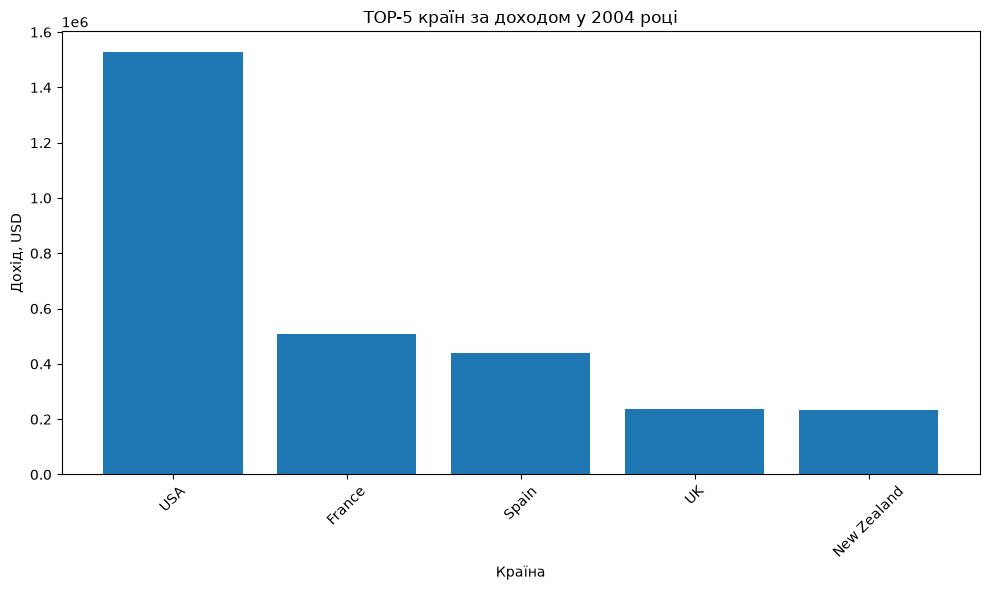

In [30]:
plt.figure(figsize=(10, 6))

plt.bar(
    top_countries["country"],
    top_countries["total_revenue"]
)

plt.title("TOP-5 країн за доходом у 2004 році")
plt.xlabel("Країна")
plt.ylabel("Дохід, USD")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

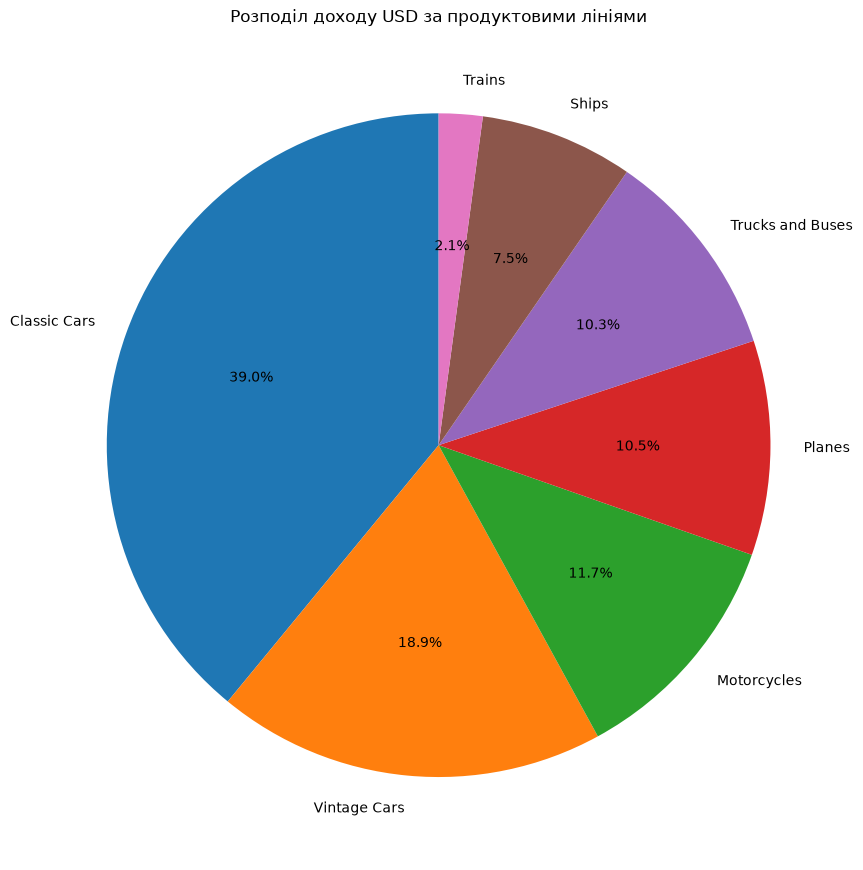

In [31]:
plt.figure(figsize=(9, 9))

plt.pie(
    product_line_analysis["total_revenue"],
    labels=product_line_analysis["productLine"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Розподіл доходу USD за продуктовими лініями"
)

plt.tight_layout()

plt.show()